In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Google Sheets linkini her zaman GÜNCEL çekecek taktik:
# Linkin sonuna eklediğimiz '&v=' kısmı Google'ın size eski veriyi vermesini engeller.
import pandas as pd
import time

# Buraya kendi gid (sayfa id) numaranı ve linkini koy
timestamp = int(time.time()) # Her seferinde farklı bir sayı üretir
url = f"https://docs.google.com/spreadsheets/d/19rN6riciEulRHiPAU1Nr-1LHSn-xVQ_BaQ2orFDh21w/export?format=csv&gid=1887374425&v={timestamp}"

df = pd.read_csv(url)
print(f"✅ En güncel veri çekildi! Satır sayısı: {len(df)}")
# O 'kulp' yorumunu kontrol edelim:
print(df[df['review_text'].str.contains("kulp", na=False)])

# Kaç satır var
print(df.shape[0])

# Son 5 satır
print(df.tail(5))

# 'Sutun_Adi' yazan yere kendi sütun ismini yazmalısın
# 'Sutun_Adi' yazan yere kendi sütun ismini yazmalısın
sonuc = df[df['review_text'].str.contains('Ürün kesinlikle orijinal değil almayın ', case=False, na=False)]
print(sonuc)

df['Etiket'].value_counts()

✅ En güncel veri çekildi! Satır sayısı: 2651
                                            review_text   Etiket  \
0     tava iyide bu kulplar nedir böyle. tutmaya yür...  Alakalı   
10    Bu kadar övülen bu tavaların kulplarının isınd...  Alakalı   
73    Ürün güzel fakat kulpları da silikon olsaydı d...  Alakalı   
88    Kulpları çok ısındığı için mutlaka bir şey kul...  Alakalı   
90    Tavanın kendisi çok güzel fakat kulpları efsan...  Alakalı   
...                                                 ...      ...   
1862      Çok ince kulpu çabuk ısınıyor hiç güzel değil  Alakalı   
1874  Çok güzel fakat tavanın kulpları çok ısınıyor ...  Alakalı   
1899  Tavalar güzel yapıştırma yapmıyor ama kulpları...  Alakalı   
1967  Tava hiç yapışmıyor çok güzel fakat kulpları ç...  Alakalı   
1987  Hafif Bi ürün. Günlük kullanıma uygun fakatttt...  Alakalı   

      review_rating  
0                 3  
10                2  
73                3  
88                3  
90                3  
...   

,count
Etiket,
Alakalı,1454
Alakasız,1197


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Stopwords hazırlığı
nltk.download('stopwords', quiet=True)
durak_kelimeler = set(stopwords.words('turkish'))

def alaka_temizligi(metin):
    metin = str(metin)
    # Python'un Türkçe 'İ' ve 'I' harflerini doğru küçültmesi için garanti yöntem
    metin = metin.replace('İ', 'i').replace('I', 'ı')

    # Senin yazdığın temizlik adımları
    metin = metin.lower()
    metin = re.sub(r'[^a-zçğıöşü\s]', '', metin)
    kelimeler = metin.split()
    temiz_kelimeler = [w for w in kelimeler if w not in durak_kelimeler]

    return " ".join(temiz_kelimeler)

# DİKKAT: Yeni sütun açmıyoruz, direkt "review_text" üzerine yazıyoruz!
df['review_text'] = df['review_text'].apply(alaka_temizligi)

# Sadece 3 başlığının kaldığını ve temizlendiğini gör:
print(df[['review_text', 'Etiket', 'review_rating']].head())

                                         review_text   Etiket  review_rating
0  tava iyide kulplar nedir böyle tutmaya yürek l...  Alakalı              3
1  ürünü iki üç kullandım hafif bir ürün çizilme ...  Alakalı              3
2  güzel yumuşak bir yastık başınızı koyduğunuzda...  Alakalı              4
3  beklentim yüksek di hayal kırıklığına uğradım ...  Alakalı              3
4  kaliteli bişey beklemeyin hafif sarmadan kutus...  Alakalı              3


In [ ]:
!pip install catboost
!pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Modeller
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# --- 1. VERİ GÜVENLİĞİ VE HAZIRLIK ---
df['review_rating'] = pd.to_numeric(df['review_rating'], errors='coerce').fillna(3.0)

# DİKKAT: Burayı küçük harf 'etiket' olarak bıraktım (Önceki hatayı almamak için)
df['Etiket_Sayisal'] = df['Etiket'].astype(str).str.strip().map({
    'Alakasız': 1, 'Alakalı': 0,
    '1': 1, '0': 0,
    '1.0': 1, '0.0': 0
})

df = df.dropna(subset=['review_text', 'Etiket_Sayisal'])

X = df[['review_text', 'review_rating']]
y = df['Etiket_Sayisal'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. TRANSFORMER ---
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1,2), max_features=5000), 'review_text'),
        ('num', 'passthrough', ['review_rating'])
    ])

# --- 3. VOLTRAN'I HAZIRLAMA (AI Topluluğu) ---
rf = RandomForestClassifier(random_state=42)
svm = SVC(kernel='linear', probability=True)
cat = CatBoostClassifier(iterations=100, verbose=False)

voltran = VotingClassifier(
    estimators=[('rf', rf), ('svm', svm), ('cat', cat)],
    voting='soft'
)

# --- 4. BİRLEŞTİRİLMİŞ MODELLER LİSTESİ ---
# Tüm şampiyonlar tek bir çatıda!
modeller = {
    "Lojistik Regresyon": Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000))]),
    "Naive Bayes": Pipeline([('prep', preprocessor), ('clf', MultinomialNB())]),
    "SVM (Destek Vektör)": Pipeline([('prep', preprocessor), ('clf', svm)]),
    "Random Forest": Pipeline([('prep', preprocessor), ('clf', rf)]),
    "CatBoost": Pipeline([('prep', preprocessor), ('clf', cat)]),
    "XGBoost (Kaggle Kralı)": Pipeline([('prep', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))]),
    "VOLTRAN (Yapay Zeka)": Pipeline([('prep', preprocessor), ('clf', voltran)])
}

# --- 5. PRO MEGA YARIŞ ---
en_iyi_model = ""
en_iyi_f1 = 0

print("🏁 PRO MEGA YARIŞ BAŞLIYOR... (F1 Skoruna Göre Sıralanacaktır)\n")
print(f"{'MODEL ADI':<25} | {'ACCURACY':<10} | {'F1 (Alakasız)':<15} | {'RECALL (Yakalama)':<15}")
print("-" * 75)

for model_adi, pipeline in modeller.items():
    pipeline.fit(X_train, y_train)
    tahminler = pipeline.predict(X_test)

    acc = accuracy_score(y_test, tahminler)
    f1 = f1_score(y_test, tahminler, zero_division=0)
    recall = recall_score(y_test, tahminler, zero_division=0)

    print(f"{model_adi:<25} | %{acc * 100:<9.1f} | %{f1 * 100:<14.1f} | %{recall * 100:<14.1f}")

    if f1 > en_iyi_f1:
        en_iyi_f1 = f1
        en_iyi_model = model_adi

print("-" * 75)
print(f"🏆 YENİ ŞAMPİYON: {en_iyi_model} (F1: %{en_iyi_f1 * 100:.1f})")

🏁 PRO MEGA YARIŞ BAŞLIYOR... (F1 Skoruna Göre Sıralanacaktır)

MODEL ADI                 | ACCURACY   | F1 (Alakasız)   | RECALL (Yakalama)
---------------------------------------------------------------------------
Lojistik Regresyon        | %88.9      | %87.9           | %89.6          
Naive Bayes               | %88.3      | %85.4           | %75.8          
SVM (Destek Vektör)       | %91.1      | %90.1           | %88.8          
Random Forest             | %90.2      | %89.5           | %92.1          
CatBoost                  | %88.7      | %87.6           | %88.3          


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:13:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (Kaggle Kralı)    | %90.0      | %89.2           | %91.7          
VOLTRAN (Yapay Zeka)      | %91.5      | %90.7           | %91.2          
---------------------------------------------------------------------------
🏆 YENİ ŞAMPİYON: VOLTRAN (Yapay Zeka) (F1: %90.7)


# 1. Adım: SVM (Destek Vektör Makineleri) Optimizasyonu
SVM, metin sınıflandırmada klasikler arasında genellikle en yüksek skoru veren modeldir. C ve kernel parametreleriyle oynayarak %91.1'i yukarı çekmeye çalışalım.

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Pipeline'ı senin yapına uygun kuruyoruz
# Senin 'preprocessor' değişkenini aynen kullanıyoruz
svm_optimize_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', SVC(probability=True))
])

# 2. Denenecek parametreler
# Not: 'prep__text__ngram_range' -> preprocessor içindeki 'text' isimli transformer'ın ngram ayarı
param_grid = {
    'prep__text__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf']
}

print("🚀 SVM için 'ColumnTransformer' uyumlu GridSearch başlatıldı...")
# n_jobs=-1 işlemciyi tam kapasite kullanır
grid_svm = GridSearchCV(svm_optimize_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)

# Sen zaten X_train ve y_train'i yukarıdaki kodda ayırmıştın, direkt basıyoruz
grid_svm.fit(X_train, y_train)

print(f"\n🏆 SVM En İyi Skor: %{grid_svm.best_score_*100:.2f}")
print(f"🛠️ En İyi Ayarlar: {grid_svm.best_params_}")

🚀 SVM için 'ColumnTransformer' uyumlu GridSearch başlatıldı...

🏆 SVM En İyi Skor: %87.23
🛠️ En İyi Ayarlar: {'clf__C': 10, 'clf__kernel': 'rbf', 'prep__text__ngram_range': (1, 1)}


# 2. Adım: Random Forest Optimizasyonu

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline
rf_optimize_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Parametreler
param_grid_rf = {
    'clf__n_estimators': [100, 300], # Ağaç sayısı
    'clf__max_depth': [None, 10, 20],   # Derinlik
    'prep__text__ngram_range': [(1, 1)] # SVM'den öğrendik, 1,1 daha güvenli olabilir
}

print("🌲 Random Forest için GridSearch başlatıldı...")
grid_rf = GridSearchCV(rf_optimize_pipeline, param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"\n🏆 Random Forest En İyi Skor: %{grid_rf.best_score_*100:.2f}")
print(f"🛠️ En İyi Ayarlar: {grid_rf.best_params_}")

🌲 Random Forest için GridSearch başlatıldı...

🏆 Random Forest En İyi Skor: %86.58
🛠️ En İyi Ayarlar: {'clf__max_depth': None, 'clf__n_estimators': 300, 'prep__text__ngram_range': (1, 1)}


# 3. Adım: XGBoost (Kaggle Kralı) Optimizasyonu

In [ ]:
# En iyi ayarları birleştirip VOLTRAN'ı (Ultra Yapay Zeka) tekrar kuruyoruz
final_rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
final_svm = SVC(C=10, kernel='rbf', probability=True)
final_cat = CatBoostClassifier(iterations=100, verbose=False)

# Preprocessor'da öğrendiğimiz en iyi ngram'ı (1,1) kullanıyoruz
final_preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1,1), max_features=5000), 'review_text'),
        ('num', 'passthrough', ['review_rating'])
    ])

ultra_voltran = VotingClassifier(
    estimators=[('rf', final_rf), ('svm', final_svm), ('cat', final_cat)],
    voting='soft'
)

# Tek bir pipeline olarak eğitelim
final_pipeline = Pipeline([
    ('prep', final_preprocessor),
    ('clf', ultra_voltran)
])

final_pipeline.fit(X_train, y_train)
final_tahminler = final_pipeline.predict(X_test)

print(f"🔥 ULTRA VOLTRAN F1 SKORU: %{f1_score(y_test, final_tahminler)*100:.2f}")

🔥 ULTRA VOLTRAN F1 SKORU: %91.70


📊 --- ULTRA VOLTRAN AKADEMİK PERFORMANS RAPORU --- 📊

METRİK               | DEĞER     
-----------------------------------
Accuracy             | %92.47
F1-Score (Alakasız)  | %91.70
Precision            | %91.32
Recall               | %92.08
-----------------------------------

📝 DETAYLI SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

 Alakalı (0)       0.93      0.93      0.93       291
Alakasız (1)       0.91      0.92      0.92       240

    accuracy                           0.92       531
   macro avg       0.92      0.92      0.92       531
weighted avg       0.92      0.92      0.92       531



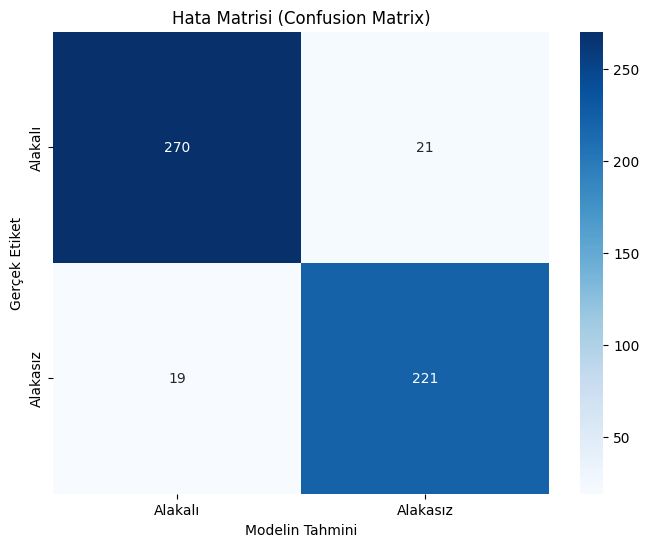

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Tahminleri alıyoruz
final_tahminler = final_pipeline.predict(X_test)

# Metrikleri hesaplayalım
acc = accuracy_score(y_test, final_tahminler)
f1 = f1_score(y_test, final_tahminler)
prec = precision_score(y_test, final_tahminler)
rec = recall_score(y_test, final_tahminler)

print("📊 --- ULTRA VOLTRAN AKADEMİK PERFORMANS RAPORU --- 📊\n")
print(f"{'METRİK':<20} | {'DEĞER':<10}")
print("-" * 35)
print(f"{'Accuracy':<20} | %{acc*100:.2f}")
print(f"{'F1-Score (Alakasız)':<20} | %{f1*100:.2f}")
print(f"{'Precision':<20} | %{prec*100:.2f}")
print(f"{'Recall':<20} | %{rec*100:.2f}")
print("-" * 35)

# Detaylı Sınıflandırma Raporu (Hocanın en sevdiği kısım)
print("\n📝 DETAYLI SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, final_tahminler, target_names=['Alakalı (0)', 'Alakasız (1)']))

# Confusion Matrix (Hata Matrisi) Görselleştirme
cm = confusion_matrix(y_test, final_tahminler)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Alakalı', 'Alakasız'], yticklabels=['Alakalı', 'Alakasız'])
plt.title('Hata Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket')
plt.xlabel('Modelin Tahmini')
plt.show()


==================== SVM (Optimized) ANALİZ RAPORU ====================
Accuracy           : %92.28
F1-Score (1)       : %91.48
Precision (1)      : %91.29
Recall (1)         : %91.67

Sınıflandırma Detayları:
              precision    recall  f1-score   support

 Alakalı (0)       0.93      0.93      0.93       291
Alakasız (1)       0.91      0.92      0.91       240

    accuracy                           0.92       531
   macro avg       0.92      0.92      0.92       531
weighted avg       0.92      0.92      0.92       531



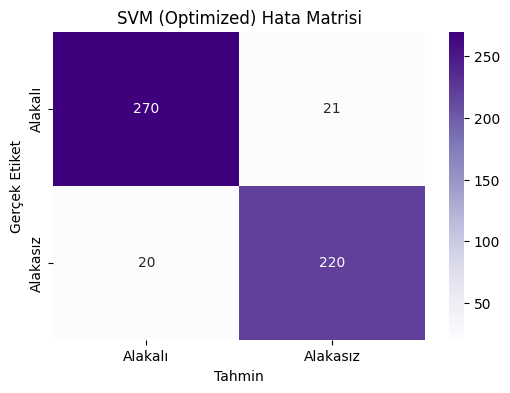




==================== Random Forest (Optimized) ANALİZ RAPORU ====================
Accuracy           : %92.09
F1-Score (1)       : %91.25
Precision (1)      : %91.25
Recall (1)         : %91.25

Sınıflandırma Detayları:
              precision    recall  f1-score   support

 Alakalı (0)       0.93      0.93      0.93       291
Alakasız (1)       0.91      0.91      0.91       240

    accuracy                           0.92       531
   macro avg       0.92      0.92      0.92       531
weighted avg       0.92      0.92      0.92       531



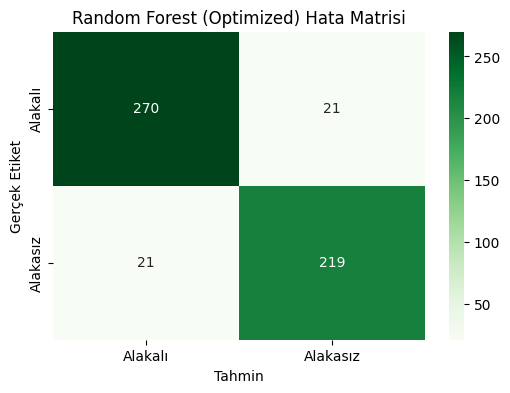

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. EN İYİ MODELLERİ TANIMLIYORUZ (GridSearch sonuçlarına göre)
modeller_analiz = {
    "SVM (Optimized)": SVC(C=10, kernel='rbf', probability=True),
    "Random Forest (Optimized)": RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
}

# Preprocessor'ı (ngram: 1,1) tekrar kuruyoruz
analiz_preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1,1), max_features=5000), 'review_text'),
        ('num', 'passthrough', ['review_rating'])
    ])

# 2. ANALİZ DÖNGÜSÜ
for isim, model in modeller_analiz.items():
    print(f"\n{'='*20} {isim} ANALİZ RAPORU {'='*20}")

    # Pipeline kur ve eğit
    temp_pipeline = Pipeline([
        ('prep', analiz_preprocessor),
        ('clf', model)
    ])
    temp_pipeline.fit(X_train, y_train)
    tahminler = temp_pipeline.predict(X_test)

    # Metrikleri hesapla
    acc = accuracy_score(y_test, tahminler)
    f1 = f1_score(y_test, tahminler)
    prec = precision_score(y_test, tahminler)
    rec = recall_score(y_test, tahminler)

    # Ekrana yazdır
    print(f"Accuracy           : %{acc*100:.2f}")
    print(f"F1-Score (1)       : %{f1*100:.2f}")
    print(f"Precision (1)      : %{prec*100:.2f}")
    print(f"Recall (1)         : %{rec*100:.2f}")
    print("\nSınıflandırma Detayları:")
    print(classification_report(y_test, tahminler, target_names=['Alakalı (0)', 'Alakasız (1)']))

    # Hata Matrisi Çizimi
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, tahminler)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if "Forest" in isim else 'Purples',
                xticklabels=['Alakalı', 'Alakasız'], yticklabels=['Alakalı', 'Alakasız'])
    plt.title(f'{isim} Hata Matrisi')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin')
    plt.show()
    print("\n")